### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [3]:
df = pd.read_csv("mymoviedb.csv")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


### Understand Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [5]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [6]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')

In [7]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], format='mixed', errors='coerce')
df['Release_Date'] = df['Release_Date'].dt.year

In [8]:
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   float64
 1   Title              9826 non-null   object 
 2   Overview           9826 non-null   object 
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   float64
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9826 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(4), object(5)
memory usage: 767.7+ KB


### Understand Data

In [1]:
df['Release_Date'] = df['Release_Date'].astype(int)

NameError: name 'df' is not defined

### Most Frequent Genre

In [11]:
df['Genre'] = df['Genre'].str.split(',')
df_exploded = df.explode('Genre')
df_exploded['Genre'].value_counts().head(10)

Genre
 Thriller     1973
 Drama        1953
Drama         1791
Action        1570
 Comedy       1547
Comedy        1484
 Adventure    1267
 Romance      1172
 Action       1116
 Family       1064
Name: count, dtype: int64

### Highest Rated Movie

In [15]:
df.sort_values(by='Vote_Average', ascending=False)[['Title','Vote_Average']].head(5)

,Title,Vote_Average
9401,Kung Fu Master Huo Yuanjia,10.0
7349,Franco Escamilla: Por La Anécdota,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
2335,Impossible Things,9.1
7411,My Sex Doll,9.0


### Most Popular Movie

In [16]:
df.sort_values(by='Popularity', ascending=False)[['Title','Popularity','Genre']].head(5)

,Title,Popularity,Genre
0,Spider-Man: No Way Home,5083.954,"[Action, Adventure, Science Fiction]"
1,The Batman,3827.658,"[Crime, Mystery, Thriller]"
2,No Exit,2618.087,[Thriller]
3,Encanto,2402.201,"[Animation, Comedy, Family, Fantasy]"
4,The King's Man,1895.511,"[Action, Adventure, Thriller, War]"


### Least Popular Movie

In [24]:
df.sort_values(by='Popularity')[['Title','Popularity','Genre']].head(5)

,Title,Popularity,Genre
9836,Threads,13.354,"[War, Drama, Science Fiction]"
9835,The United States vs. Billie Holiday,13.354,"[Music, Drama, History]"
9834,The Offering,13.355,"[Mystery, Thriller, Horror]"
9833,Violent Delights,13.356,[Horror]
9831,The Little Prince,13.357,"[Science Fiction, Fantasy, Family, Music]"


### Year with Most Movies

In [18]:
df['Release_Date'].value_counts().head()

Release_Date
2021    714
2018    530
2017    510
2019    500
2016    470
Name: count, dtype: int64

## Visualization

### Movies per Year

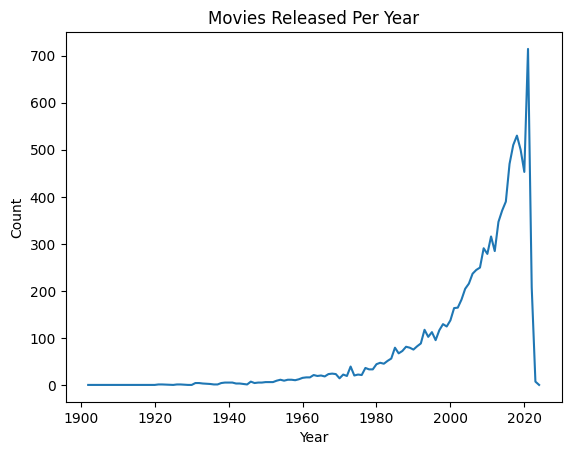

In [20]:
df['Release_Date'].value_counts().sort_index().plot()
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Top Genres

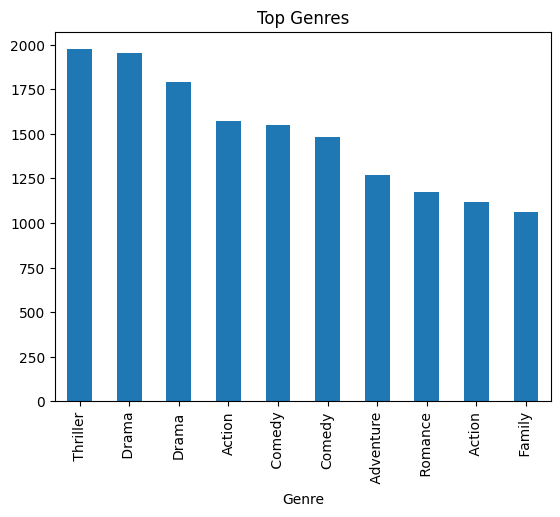

In [25]:
df_exploded['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

### Language Distribution

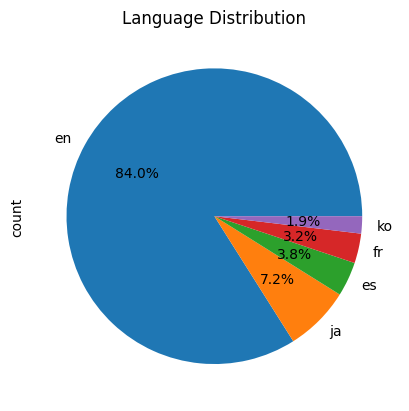

In [22]:
df['Original_Language'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Language Distribution")
plt.show()